# Model Evaluation - Accuracy & Confusion Matrix

## Setup

In [1]:
import sys
import os
import json

sys.path.append(os.path.abspath(os.path.join("..", "app", "modules")))

from main_agent import decide_action

## Load the labeled conversations

In [2]:
with open(os.path.join("..", "data", "sms_conversations.json"), "r", encoding="utf-8") as f:
    conversations = json.load(f)

print("number of conversations:", len(conversations))

number of conversations: 15


## Build the evaluation examples

In [3]:
examples = []

for conv in conversations:
    history = ""
    for turn in conv["turns"]:
        if turn["speaker"] == "recruiter" and turn["label"] is not None and history != "":
            examples.append({"history": history.strip(), "label": turn["label"]})
        history = history + turn["speaker"] + ": " + turn["text"] + "\n"

print("number of evaluation examples:", len(examples))

number of evaluation examples: 44


## Run the Main Agent on every example

In [4]:
predictions = []
true_labels = []

for i, ex in enumerate(examples):
    pred = decide_action(ex["history"])
    predictions.append(pred)
    true_labels.append(ex["label"])
    print(i + 1, "/", len(examples), "true:", ex["label"], "| predicted:", pred)

1 / 44 true: schedule | predicted: schedule
2 / 44 true: schedule | predicted: schedule
3 / 44 true: end | predicted: end
4 / 44 true: continue | predicted: schedule
5 / 44 true: continue | predicted: continue
6 / 44 true: schedule | predicted: schedule
7 / 44 true: end | predicted: end
8 / 44 true: continue | predicted: schedule
9 / 44 true: continue | predicted: continue
10 / 44 true: end | predicted: end
11 / 44 true: continue | predicted: schedule
12 / 44 true: continue | predicted: continue
13 / 44 true: end | predicted: end
14 / 44 true: schedule | predicted: schedule
15 / 44 true: end | predicted: end
16 / 44 true: schedule | predicted: schedule
17 / 44 true: end | predicted: end
18 / 44 true: schedule | predicted: schedule
19 / 44 true: schedule | predicted: schedule
20 / 44 true: end | predicted: end
21 / 44 true: schedule | predicted: schedule
22 / 44 true: schedule | predicted: schedule
23 / 44 true: schedule | predicted: end
24 / 44 true: end | predicted: end
25 / 44 true: 

## Accuracy

In [5]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predictions)
print("Accuracy:", round(accuracy, 3))

Accuracy: 0.795


## Confusion Matrix

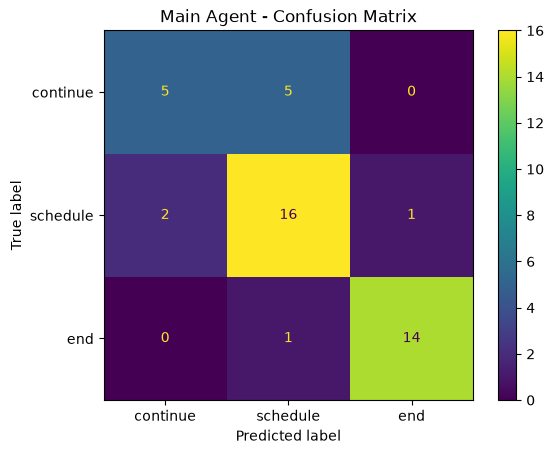

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["continue", "schedule", "end"]
cm = confusion_matrix(true_labels, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Main Agent - Confusion Matrix")
plt.show()